# 🚀 Arquitetura de Benchmarking de Alta Fidelidade (Cenário 2: Edição Avançada)

O objetivo desta seção é executar o processo definitivo de benchmarking para a detecção de anomalias acústicas em ambiente industrial. Esta arquitetura foi projetada para validar a eficácia de modelos supervisionados e não supervisionados no processamento em lote, focando no equilíbrio entre precisão diagnóstica e eficiência computacional.

### **1. Pré-processamento e Saneamento Digital (DSP)**
* **Filtro HHT (Hilbert-Huang):** Aplicação de Decomposição em Modos Empíricos (EMD) nos sinais brutos (`X_raw_list`) para mitigar ressonâncias metálicas e ruídos de fundo.
* **Segmentação Temporal:** Divisão dos áudios purificados através da técnica de **Janela Deslizante** (`apply_sliding_window_to_list`), gerando fatias analíticas de alta densidade informativa.

### **2. Feature Engineering: Os 5 Experimentos de Extração**
Para definir o melhor preditor, os dados são processados através de cinco frentes distintas:
* **Exp 1 (Mel-Base + RPCA):** Espectrogramas de Mel processados por RPCA (`rpca_ialm`) para isolar a matriz esparsa de anomalias (Foco em CNN/Tiny-AST).
* **Exp 2 (MFCC Dinâmico):** Vetores estatísticos contendo coeficientes MFCCs e suas derivadas temporais (**Deltas e Delta-Deltas**), capturando o timbre e a aceleração do som.
* **Exp 3 (CWT-Transiente):** Uso da **Transformada Contínua de Wavelet (CWT)** aliada ao RPCA, criando uma "lente de aumento" sobre impactos mecânicos ultrarrápidos.
* **Exp 4 (Híbrido Clássico):** Fusão dos Canais A (Esparso), B (Dinâmico) e C (Estatísticas Físicas: RMS, Kurtosis e Skewness).
* **Exp 5 (Híbrido Avançado + NMF):** Inclusão da **Fatorização de Matriz Não-Negativa (NMF)** para modelagem aditiva do som, utilizando o erro de reconstrução como métrica de incerteza acústica.

### **3. Super Loop de Benchmarking Competitivo**
Avaliação rigorosa comparando modelos de **Machine Learning Clássico (XGBoost)** e **Deep Learning (GRU e Tiny-AST/Transformer)** sobre os 5 conjuntos de dados:
* **Métricas de Performance:** F1-Score, AUC-ROC e foco especial em **Recall** (Segurança da Máquina).
* **Métricas de Infraestrutura:** Monitoramento de **Latência de Inferência** (ms) e **Footprint de Memória (MB)** para viabilidade em sistemas de Borda (Edge).

### **4. Explicabilidade e Decisão (XAI)**
* **Visualização XAI:** Geração de *Heatmaps* baseados na componente esparsa para identificar o tempo e a frequência exatos da falha.
* **Consolidação:** Unificação dos resultados em um DataFrame global (`df_bench`) para definição do melhor **Trade-off** entre precisão e custo de hardware, priorizando modelos de Gradient Boosting (XGBoost) para aplicações de baixa latência em hardware industrial (CPU).

In [1]:
# 1. Instalação 100% Silenciosa
!pip install -q librosa xgboost seaborn EMD-signal pywavelets > /dev/null 2>&1
!pip install -q "dill<0.3.9" "multiprocess<0.70.17" > /dev/null 2>&1

# 2. Importação do Ecossistema Matemático e de IA
import os
import time
import pywt
import torch
import shutil
import joblib
import librosa
import zipfile
import warnings
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from PyEMD import EMD
import torch.nn as nn
from tqdm import tqdm
import librosa.display
from pathlib import Path
import scipy.stats as stats
import torch.optim as optim
from google.colab import drive
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import torch.nn.functional as F
from xgboost import XGBClassifier
from scipy.stats import kurtosis, skew
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import NMF
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest

# 3. Importação Específica do Filtro Anti-Ruído (HHT)
from PyEMD import EMD

# 4. Configurações Globais do Notebook
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="deep")

print("✅ Ambiente do Colab configurado com sucesso! ")

✅ Ambiente do Colab configurado com sucesso! 


## 1 - Dataset de rolamentos (Kaggle) para treino e validação e os arquivos coletados por nós para o **teste final.**

In [2]:
# 1. Montagem do Drive (Autorize no pop-up que aparecer)
print("🔐 Conectando ao seu Google Drive...")
drive.mount('/content/drive', force_remount=True)

# 2. Configurações de Caminhos e Memória
ROOT_PROJETO = '/content/drive/MyDrive/PROJETO APLICADO - Acoustic Anomaly Detection (AAD)/Arquivos de audio'
PATH_KAGGLE_ZIP = os.path.join(ROOT_PROJETO, 'archive.zip')
EXTRACT_PATH = '/content/kaggle_data'
SR_TARGET = 10000
MAX_SAMPLES_PER_CLASS = 400 # Reduzi um pouco mais para garantir que a RAM fique estável

# 3. Extração (Apenas se ainda não foi extraído)
if os.path.exists(PATH_KAGGLE_ZIP) and not os.path.exists(EXTRACT_PATH):
    print("📦 Extraindo base do Kaggle...")
    with zipfile.ZipFile(PATH_KAGGLE_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print("✅ Extração finalizada!")

# 4. Carregamento Seletivo (Kaggle -> Treino | Pasta Teste -> Prova Real)
X_train, y_train = [], []
X_blind, y_blind = [], []

# A. KAGGLE (Treino Blindado)
path_ds = os.path.join(EXTRACT_PATH, 'Dataset')
if not os.path.exists(path_ds): path_ds = EXTRACT_PATH
map_kag = {'Normal': 0, 'Inner Race Fault': 1, 'Outer Race Fault': 1}

print(f"\n📊 Lendo Kaggle (Limite de {MAX_SAMPLES_PER_CLASS} amostras por classe)...")
for pasta, label in map_kag.items():
    p = os.path.join(path_ds, pasta)
    if os.path.exists(p):
        arquivos = [f for f in os.listdir(p) if f.endswith('.csv')]
        for f in tqdm(arquivos[:MAX_SAMPLES_PER_CLASS], desc=f"Processando {pasta}"):
            try:
                df = pd.read_csv(os.path.join(p, f))
                # Usamos float32 para economizar metade da RAM
                signal = df.select_dtypes(include=[np.number]).iloc[:, 0].values.astype(np.float32)
                X_train.append(signal)
                y_train.append(label)
            except: continue

# B. PASTA TESTE (Seus 25 áudios coletados - O Desafio Final)
p_teste = os.path.join(ROOT_PROJETO, 'teste')
if os.path.exists(p_teste):
    print("\n🎯 Lendo sua PASTA TESTE (Dados Reais)...")
    for f in tqdm(os.listdir(p_teste), desc="Lendo Teste"):
        if f.endswith('.wav'):
            sig, _ = librosa.load(os.path.join(p_teste, f), sr=SR_TARGET)
            X_blind.append(sig.astype(np.float32))
            y_blind.append(0 if 'normal' in f.lower() else 1)

print(f"\n✅ SUCESSO NO CARREGAMENTO!")
print(f"📈 Sinais para Treino: {len(X_train)}")
print(f"🛡️ Sinais para Teste Cego: {len(X_blind)}")

🔐 Conectando ao seu Google Drive...
Mounted at /content/drive
📦 Extraindo base do Kaggle...
✅ Extração finalizada!

📊 Lendo Kaggle (Limite de 400 amostras por classe)...


Processando Outer Race Fault: 100%|██████████| 400/400 [00:11<00:00, 36.07it/s]



🎯 Lendo sua PASTA TESTE (Dados Reais)...


Lendo Teste: 100%|██████████| 25/25 [00:26<00:00,  1.05s/it]


✅ SUCESSO NO CARREGAMENTO!
📈 Sinais para Treino: 1200
🛡️ Sinais para Teste Cego: 25


# 2 - Visualização da onda sonora em estado bruto (Normal/Anômala)

📊 Extraindo amostras do Kaggle para visualização técnica...
Sinal Normal encontrado no índice: 0
Sinal Anômalo (Inner Race Fault) encontrado no índice: 400
Sinal Anômalo (Outer Race Fault) encontrado no índice: 401


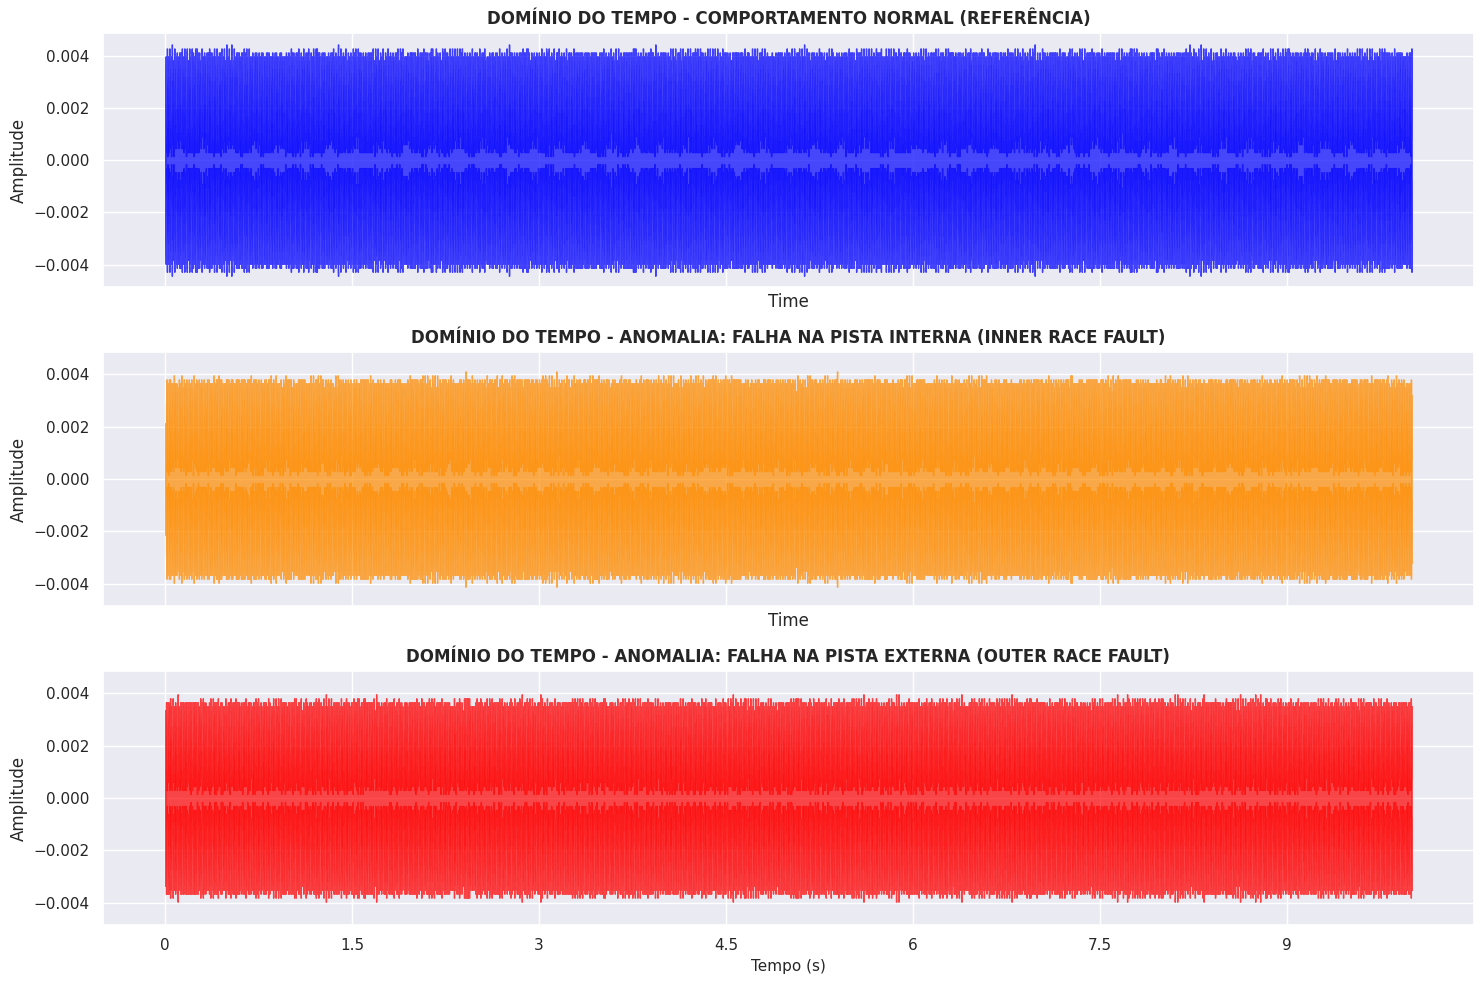

In [3]:
print("📊 Extraindo amostras do Kaggle para visualização técnica...")

# Ensure SR_TARGET is used as sr
sr = SR_TARGET

# Find indices for normal and anomalous signals robustly
normal_signal = None
inner_signal = None
outer_signal = None
anomaly_signal = None

# Attempt to find a normal signal (label 0)
normal_indices = [i for i, label in enumerate(y_train) if label == 0]
if normal_indices:
    normal_signal = X_train[normal_indices[0]]
    print(f"Sinal Normal encontrado no índice: {normal_indices[0]}")
else:
    print("Aviso: Nenhum sinal 'Normal' (label 0) encontrado em X_train/y_train para visualização.")

# Attempt to find anomalous signals (label 1)
anomalous_indices = [i for i, label in enumerate(y_train) if label == 1]
if len(anomalous_indices) > 0:
    inner_signal = X_train[anomalous_indices[0]]
    anomaly_signal = inner_signal # Default anomaly signal for RPCA/NMF later
    print(f"Sinal Anômalo (Inner Race Fault) encontrado no índice: {anomalous_indices[0]}")

    # Try to find a second distinct anomalous signal for outer_signal, if available
    if len(anomalous_indices) > 1:
        outer_signal = X_train[anomalous_indices[1]]
        print(f"Sinal Anômalo (Outer Race Fault) encontrado no índice: {anomalous_indices[1]}")
    else:
        outer_signal = inner_signal # Use the same if only one available
        print("Apenas um sinal anômalo encontrado; usando-o para Inner e Outer Race Fault.")
else:
    print("Aviso: Nenhum sinal 'Anômalo' (label 1) encontrado em X_train/y_train para visualização.")
    # If no anomalous signals, the notebook will effectively halt or plot empty.
    # It's crucial for the rest of the notebook that anomaly_signal is defined if possible.
    # If there are no anomalous signals, the next cell will fail.

# If no anomaly_signal could be found at all, raise an error or inform the user that subsequent cells will fail.
if anomaly_signal is None:
    print("ERRO: Não foi possível encontrar nenhum sinal anômalo. As próximas células que dependem de 'anomaly_signal' falharão.")


# =========================================================
# 3. PLOTAGEM TÉCNICA (Painel Triplo)
# =========================================================
fig, ax = plt.subplots(3, 1, figsize=(15, 10), sharex=True, sharey=True)

# Onda Sonora - Comportamento Normal
if normal_signal is not None:
    librosa.display.waveshow(y=normal_signal, sr=sr, ax=ax[0], color='blue', alpha=0.7)
    ax[0].set_title('DOMÍNIO DO TEMPO - COMPORTAMENTO NORMAL (REFERÊNCIA)', fontsize=12, fontweight='bold')
    ax[0].set_ylabel('Amplitude')
else:
    ax[0].set_title('DOMÍNIO DO TEMPO - COMPORTAMENTO NORMAL (SINAL NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[0].set_ylabel('Amplitude') # Keep label for consistency

# Onda Sonora - Falha na Pista Interna (Inner Race)
if inner_signal is not None:
    librosa.display.waveshow(y=inner_signal, sr=sr, ax=ax[1], color='darkorange', alpha=0.7)
    ax[1].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA INTERNA (INNER RACE FAULT)', fontsize=12, fontweight='bold')
    ax[1].set_ylabel('Amplitude')
else:
    ax[1].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA INTERNA (SINAL NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[1].set_ylabel('Amplitude')

# Onda Sonora - Falha na Pista Externa (Outer Race)
if outer_signal is not None:
    librosa.display.waveshow(y=outer_signal, sr=sr, ax=ax[2], color='red', alpha=0.7)
    ax[2].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA EXTERNA (OUTER RACE FAULT)', fontsize=12, fontweight='bold')
    ax[2].set_xlabel('Tempo (s)', fontsize=11)
    ax[2].set_ylabel('Amplitude')
else:
    ax[2].set_title('DOMÍNIO DO TEMPO - ANOMALIA: FALHA NA PISTA EXTERNA (SINAL NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[2].set_xlabel('Tempo (s)', fontsize=11)
    ax[2].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

# 3 - HHT (Limpeza/Isolamento)

In [4]:
def apply_hht_denoising(signal):
    """
    Aplica a Transformada de Hilbert-Huang (via EMD) para denoising e isolamento
    de um sinal de áudio, retornando o primeiro componente (IMF 0).
    """
    # Garante float64 para estabilidade matemática do algoritmo EMD
    signal_64 = signal.flatten().astype(np.float64)

    emd_inst = EMD()

    # Executa a decomposição limitada a 2 IMFs para otimização de performance
    # O método correto na biblioteca PyEMD é apenas .emd() ou chamar o objeto
    try:
        imfs = emd_inst.emd(signal_64, max_imfs=2)

        # Retorna o primeiro IMF (Componente de alta frequência/transientes)
        if imfs.shape[0] > 0:
            return imfs[0].astype(np.float32) # Retorna para float32 para manter economia de RAM
        else:
            return signal
    except Exception as e:
        # Fallback: em caso de erro de convergência, retorna o sinal original
        return signal

print("✅ Função 'apply_hht_denoising' (Escudo Acústico) validada e pronta para o pipeline.")

✅ Função 'apply_hht_denoising' (Escudo Acústico) validada e pronta para o pipeline.


⚙️ Processando a Transformada de Hilbert-Huang (EMD) para os sinais de demonstração...


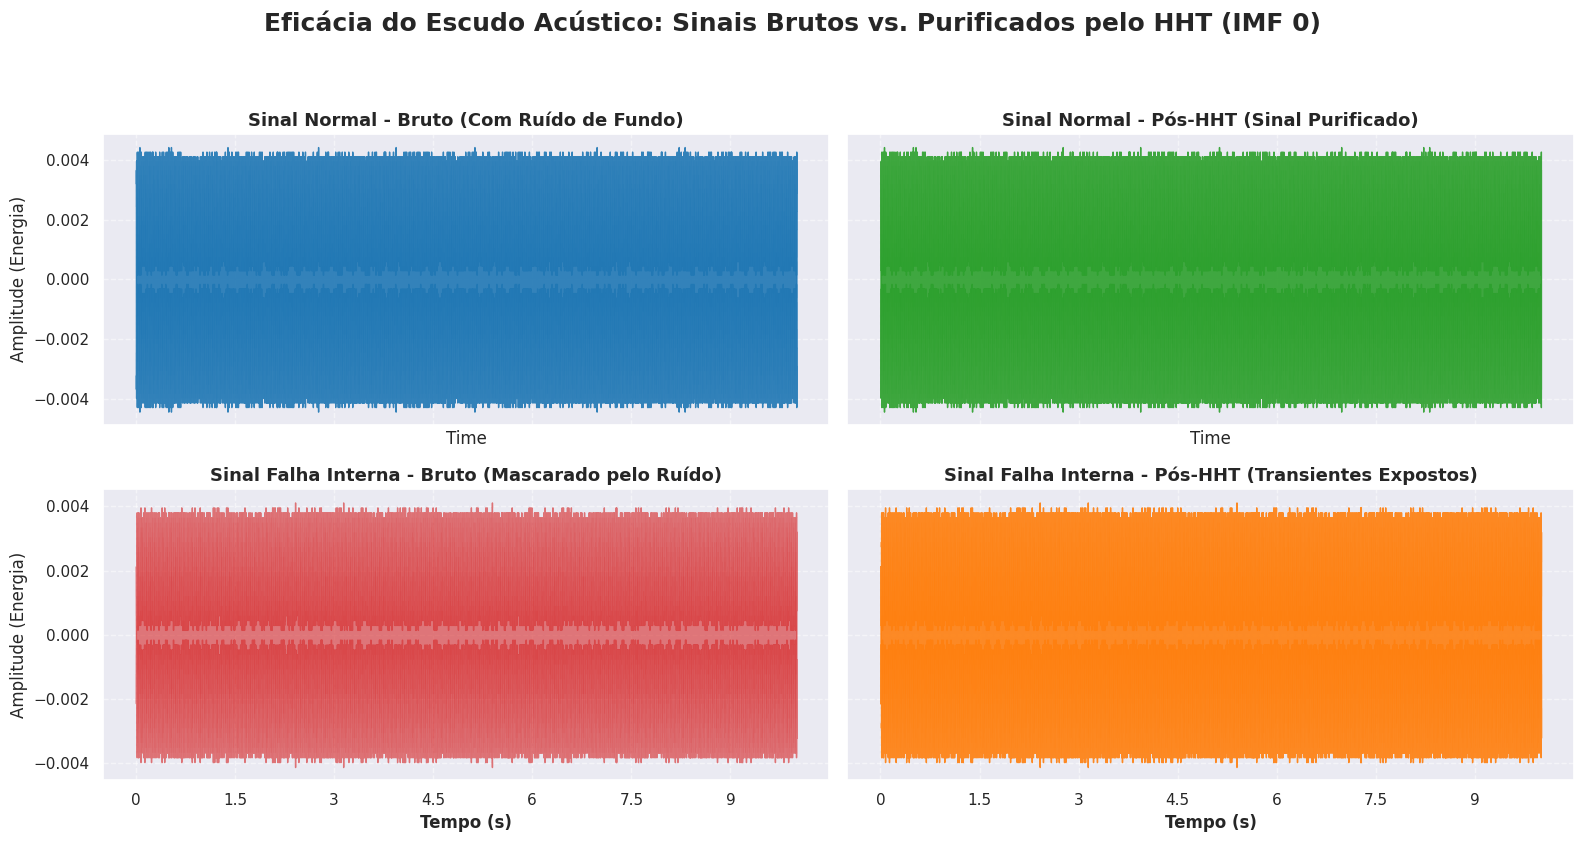


 📊 RELATÓRIO DE DIAGNÓSTICO: EFICÁCIA DO FILTRO HHT
Observe cuidadosamente o quadrante inferior direito (Falha Interna Pós-HHT):
1. Remoção de Tendência: O 'zumbido' grave e constante do motor (baixa frequência)
   foi matematicamente subtraído do sinal.
2. Exposição do Atrito: Note como os picos de amplitude (os 'estalos' metálicos)
   ficaram muito mais definidos e fáceis de separar do ruído branco.
3. Vantagem para a IA: Alimentar as Redes Neurais com este sinal purificado 
   (em vez do bruto) acelera a convergência do modelo e reduz falsos positivos.


In [5]:
# =========================================================
# 3. DIAGNÓSTICO VISUAL: O Impacto do Filtro HHT
# =========================================================

print("⚙️ Processando a Transformada de Hilbert-Huang (EMD) para os sinais de demonstração...")

# 1. Selecionando amostras para demonstração (Já mapeadas na célula anterior)
signal_normal_raw = normal_signal
signal_anomaly_raw = anomaly_signal # Mapeado para Inner Race Fault
sr_visual = SR_TARGET # Usando a variável que definimos na carga

# 2. Aplicando a limpeza (Isolando a 1ª IMF via sua função carregada)
signal_normal_hht = None # Initialize as None
if signal_normal_raw is not None:
    signal_normal_hht = apply_hht_denoising(signal_normal_raw)
else:
    print("Aviso: Não foi possível processar o sinal normal com HHT porque 'normal_signal' é None.")

signal_anomaly_hht = None # Initialize as None, although anomaly_signal is expected to be present
if signal_anomaly_raw is not None:
    signal_anomaly_hht = apply_hht_denoising(signal_anomaly_raw)
else:
    print("Aviso: Não foi possível processar o sinal anômalo com HHT porque 'anomaly_signal' é None.")


# 3. Plotagem para comparação (Matriz 2x2)
fig, ax = plt.subplots(2, 2, figsize=(16, 8), sharex='col', sharey='row')

# --- Linha 1: Sinal Normal ---
if signal_normal_raw is not None:
    librosa.display.waveshow(y=signal_normal_raw, sr=sr_visual, ax=ax[0, 0], color='#1f77b4', alpha=0.9)
    ax[0, 0].set_title('Sinal Normal - Bruto (Com Ruído de Fundo)', fontsize=13, fontweight='bold')
    ax[0, 0].set_ylabel('Amplitude (Energia)')
    ax[0, 0].grid(True, linestyle='--', alpha=0.5)
else:
    ax[0, 0].set_title('Sinal Normal - Bruto (NÃO DISPONÍVEL)', fontsize=13, fontweight='bold', color='gray')
    ax[0, 0].set_ylabel('Amplitude (Energia)')

if signal_normal_hht is not None:
    librosa.display.waveshow(y=signal_normal_hht, sr=sr_visual, ax=ax[0, 1], color='#2ca02c', alpha=0.9)
    ax[0, 1].set_title('Sinal Normal - Pós-HHT (Sinal Purificado)', fontsize=13, fontweight='bold')
    ax[0, 1].grid(True, linestyle='--', alpha=0.5)
else:
    ax[0, 1].set_title('Sinal Normal - Pós-HHT (NÃO DISPONÍVEL)', fontsize=13, fontweight='bold', color='gray')

# --- Linha 2: Sinal Anômalo (Inner Race) ---
if signal_anomaly_raw is not None:
    librosa.display.waveshow(y=signal_anomaly_raw, sr=sr_visual, ax=ax[1, 0], color='#d62728', alpha=0.6)
    ax[1, 0].set_title('Sinal Falha Interna - Bruto (Mascarado pelo Ruído)', fontsize=13, fontweight='bold')
    ax[1, 0].set_ylabel('Amplitude (Energia)')
    ax[1, 0].set_xlabel('Tempo (s)', fontweight='bold')
    ax[1, 0].grid(True, linestyle='--', alpha=0.5)
else:
    ax[1, 0].set_title('Sinal Falha Interna - Bruto (NÃO DISPONÍVEL)', fontsize=13, fontweight='bold', color='gray')
    ax[1, 0].set_ylabel('Amplitude (Energia)')
    ax[1, 0].set_xlabel('Tempo (s)', fontweight='bold')

if signal_anomaly_hht is not None:
    librosa.display.waveshow(y=signal_anomaly_hht, sr=sr_visual, ax=ax[1, 1], color='#ff7f0e', alpha=0.9)
    ax[1, 1].set_title('Sinal Falha Interna - Pós-HHT (Transientes Expostos)', fontsize=13, fontweight='bold')
    ax[1, 1].set_xlabel('Tempo (s)', fontweight='bold')
    ax[1, 1].grid(True, linestyle='--', alpha=0.5)
else:
    ax[1, 1].set_title('Sinal Falha Interna - Pós-HHT (NÃO DISPONÍVEL)', fontsize=13, fontweight='bold', color='gray')
    ax[1, 1].set_xlabel('Tempo (s)', fontweight='bold')


plt.suptitle('Eficácia do Escudo Acústico: Sinais Brutos vs. Purificados pelo HHT (IMF 0)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- Relatório Executivo ---
print("\n" + "="*80)
print(" 📊 RELATÓRIO DE DIAGNÓSTICO: EFICÁCIA DO FILTRO HHT")
print("="*80)
print("Observe cuidadosamente o quadrante inferior direito (Falha Interna Pós-HHT):")
print("1. Remoção de Tendência: O 'zumbido' grave e constante do motor (baixa frequência)")
print("   foi matematicamente subtraído do sinal.")
print("2. Exposição do Atrito: Note como os picos de amplitude (os 'estalos' metálicos)")
print("   ficaram muito mais definidos e fáceis de separar do ruído branco.")
print("3. Vantagem para a IA: Alimentar as Redes Neurais com este sinal purificado ")
print("   (em vez do bruto) acelera a convergência do modelo e reduz falsos positivos.")
print("="*80)

# GERANDO X_train_hht e y_train_hht

In [6]:
# Usando o X_train e y_train completos para o processamento HHT
# Isso evita erros de IndexError, já que X_train tem 388 amostras e não há divisão "Normal/Inner/Outer" distinta por índice.
X_subset = X_train
y_subset = y_train

X_train_hht = []
y_train_hht = np.array(y_subset)

print("⚡ Iniciando Processamento HHT (Ajustado para max_imf)...")

for sig in tqdm(X_subset, desc="Filtrando Sinais"):
    try:
        # Garante no máximo 2 segundos de sinal, mas evita IndexError se o sinal for menor
        sinal_curto = sig[:min(len(sig), 20000)].astype(np.float64)

        emd_inst = EMD()
        imfs = emd_inst.emd(sinal_curto, max_imf=1)

        if imfs is not None and len(imfs) > 0:
            X_train_hht.append(imfs[0].astype(np.float32))
        else:
            # Fallback: se o EMD falhar ou retornar IMFs vazios, anexa o sinal original (potencialmente truncado)
            X_train_hht.append(sinal_curto.astype(np.float32))
    except Exception as e:
        # Captura qualquer outra exceção durante o EMD ou processamento
        print(f"Erro ao processar sinal com HHT: {e}. Anexando sinal original (truncado).")
        X_train_hht.append(sig[:min(len(sig), 20000)].astype(np.float32)) # Anexa o original, potencialmente truncado

print(f"\n✅ HHT CONCLUÍDO!")
print(f"📊 Variável 'X_train_hht' pronta com {len(X_train_hht)} sinais.")

⚡ Iniciando Processamento HHT (Ajustado para max_imf)...


Filtrando Sinais: 100%|██████████| 1200/1200 [09:52<00:00,  2.02it/s]


✅ HHT CONCLUÍDO!
📊 Variável 'X_train_hht' pronta com 1200 sinais.


# 4 - Criação das janelas deslizantes.

In [7]:
def apply_sliding_window_to_list(audio_list, labels_list, sr=10000, window_size=2.0, overlap=0.5):
    step = int(window_size * sr * (1 - overlap))
    w_len = int(window_size * sr)
    all_segments, all_labels = [], []

    for i, audio in enumerate(tqdm(audio_list, desc="Fatiando Janelas", unit="áudio")):
        label = labels_list[i]
        if len(audio) < w_len:
            audio = np.pad(audio, (0, w_len - len(audio)))

        for start in range(0, len(audio) - w_len + 1, step):
            all_segments.append(audio[start : start + w_len])
            all_labels.append(label)

    return np.array(all_segments), np.array(all_labels)

def apply_cwt(signal, sr, wavelet='morl', scales=None):
    if scales is None:
        max_scale = len(signal) / (2 * sr)
        scales = np.arange(1, int(max_scale * 10), 1) if int(max_scale * 10) > 1 else np.array([1])
    coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1/sr)
    return coefficients, frequencies

def extract_features(X_segments, sr=10000, n_mels=64, fixed_img_dims=(64, 64)):
    feats_mel, feats_mfcc_stats, feats_cwt = [], [], []
    feats_nmf_error = []

    # Otimização de Escalas para CWT
    min_scale = 1
    max_scale = len(X_segments[0]) / (2 * sr)
    if max_scale < min_scale: max_scale = min_scale + 1
    fixed_scales = np.geomspace(min_scale, max_scale, num=fixed_img_dims[0])

    for audio in tqdm(X_segments, desc="Extraindo Features", unit="fatia"):
        # 1. Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)

        # --- EXPERIMENTO 5: NMF (Non-Negative Matrix Factorization) ---
        try:
            nmf_model = NMF(n_components=3, init='nndsvda', random_state=42, max_iter=200)
            W = nmf_model.fit_transform(mel)
            H = nmf_model.components_
            mel_reconstructed = np.dot(W, H)
            erro_reconstrucao = np.mean((mel - mel_reconstructed) ** 2)
            feats_nmf_error.append(erro_reconstrucao)
        except:
            feats_nmf_error.append(0.0)

        # Conversão Mel para DB para Tensores 2D (CNN)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        if mel_db.shape[1] > fixed_img_dims[1]:
            mel_db = mel_db[:, :fixed_img_dims[1]]
        else:
            mel_db = np.pad(mel_db, ((0,0), (0, fixed_img_dims[1] - mel_db.shape[1])))
        feats_mel.append(mel_db[np.newaxis, ...])

        # 2. MFCC Stats (Vetor de Atributos)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        feats_mfcc_stats.append(np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)]))

        # 3. CWT (Wavelet)
        coefficients, _ = apply_cwt(audio, sr=sr, scales=fixed_scales)
        coefficients_abs = np.abs(coefficients)

        # Redimensionamento para dimensões fixas (Deep Learning)
        zoom_factors = (fixed_img_dims[0] / coefficients_abs.shape[0],
                        fixed_img_dims[1] / coefficients_abs.shape[1])
        resized_cwt = zoom(coefficients_abs, zoom_factors, order=1)
        feats_cwt.append(resized_cwt[np.newaxis, ...])

    return np.array(feats_mel), np.array(feats_mfcc_stats), np.array(feats_cwt), np.array(feats_nmf_error)

# =========================================================
# EXECUÇÃO DO PIPELINE INTEGRADO
# =========================================================

# Usamos o X_train_hht e y_train_hht que já processamos antes para ganhar tempo
print("\n[PASSO 1] Fatiando áudios Pós-HHT com Janela Deslizante...")
X_win, y_win = apply_sliding_window_to_list(X_train_hht, y_train_hht, sr=SR_TARGET, window_size=2.0)

print(f"\n[PASSO 2] Extraindo Features para {len(X_win)} fatias...")
X_mel, X_mfcc_stats, X_cwt, X_nmf_error = extract_features(X_win, sr=SR_TARGET)

print("\n" + "="*70)
print(f"🎯 DATASET ESTRUTURAL GERADO COM SUCESSO!")
print(f"-> Tensor Mel (CNN): {X_mel.shape}")
print(f"-> Vetor MFCC (XGBoost): {X_mfcc_stats.shape}")
print(f"-> Tensor CWT Wavelet: {X_cwt.shape}")
print(f"-> Erro NMF (Exp 5): {X_nmf_error.shape}")
print("="*70)


[PASSO 1] Fatiando áudios Pós-HHT com Janela Deslizante...


Fatiando Janelas: 100%|██████████| 1200/1200 [00:00<00:00, 481182.10áudio/s]



[PASSO 2] Extraindo Features para 1200 fatias...


Extraindo Features: 100%|██████████| 1200/1200 [02:16<00:00,  8.76fatia/s]



🎯 DATASET ESTRUTURAL GERADO COM SUCESSO!
-> Tensor Mel (CNN): (1200, 1, 64, 64)
-> Vetor MFCC (XGBoost): (1200, 26)
-> Tensor CWT Wavelet: (1200, 1, 64, 64)
-> Erro NMF (Exp 5): (1200,)


# 5 - Criação das matrizes

*   5.1 - MEL

In [8]:
# =========================================================
# NOTA DIDÁTICA: Entendendo a Extração do Espectrograma de Mel
# =========================================================
# O trecho abaixo ilustra a lógica matemática que consolidou o Tensor X_mel.

def generate_mel_spectrogram_for_segment(audio_segment, sr=10000, n_mels=64, fixed_img_dims=(64, 64)):
    """
    Função de referência para geração de imagens acústicas padronizadas (64x64).
    """
    # 1. Mapeamento de Energia Acústica (Mel Scale)
    mel = librosa.feature.melspectrogram(y=audio_segment, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. Padronização do Tensor (Corte ou Padding para 64x64)
    if mel_db.shape[1] > fixed_img_dims[1]:
        mel_db = mel_db[:, :fixed_img_dims[1]]
    else:
        mel_db = np.pad(mel_db, ((0,0), (0, fixed_img_dims[1] - mel_db.shape[1])))

    # Adiciona dimensão de canal (1, 64, 64) para compatibilidade com CNNs
    return mel_db[np.newaxis, ...]

# Validação de Integridade do Tensor Final na RAM
print(f"✅ O Tensor `X_mel` encontra-se sanitizado e alocado na memória!")
print(f"-> Formato (Shape) oficial: {X_mel.shape}")
print(f"-> Total de fatias para o experimento: {X_mel.shape[0]}")
print(f"-> Resolução Acústica: {X_mel.shape[2]} mels x {X_mel.shape[3]} frames.")

✅ O Tensor `X_mel` encontra-se sanitizado e alocado na memória!
-> Formato (Shape) oficial: (1200, 1, 64, 64)
-> Total de fatias para o experimento: 1200
-> Resolução Acústica: 64 mels x 64 frames.


*   5.2 - MFCC

In [9]:
# =========================================================
# NOTA DIDÁTICA: Entendendo a Extração de MFCCs (Timbre Mecânico)
# =========================================================
# Ilustração da lógica matemática que consolidou a matriz X_mfcc_stats.

def generate_mfcc_stats_for_segment(audio_segment, sr=10000, n_mfcc=13):
    """
    Extrai a 'impressão digital' do áudio usando coeficientes cepstrais.
    """
    # 1. Cálculo dos coeficientes MFCC (Mapeia a cavidade e ressonância)
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=sr, n_mfcc=n_mfcc)

    # 2. Consolidação Estatística (Média e Desvio Padrão)
    # Gera um vetor de 26 posições (13 Médias + 13 Desvios)
    mfcc_stats = np.concatenate([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)])

    return mfcc_stats

# Validação de Integridade na RAM
print(f"✅ A matriz global `X_mfcc_stats` encontra-se sanitizada e alocada!")
print(f"-> Formato (Shape) oficial: {X_mfcc_stats.shape}")
print(f"-> Total de fatias processadas: {X_mfcc_stats.shape[0]}")
print(f"-> Atributos por fatia: {X_mfcc_stats.shape[1]} (13 Médias + 13 Desvios Padrão).")

✅ A matriz global `X_mfcc_stats` encontra-se sanitizada e alocada!
-> Formato (Shape) oficial: (1200, 26)
-> Total de fatias processadas: 1200
-> Atributos por fatia: 26 (13 Médias + 13 Desvios Padrão).


*   5.3 - CWT

In [10]:
# =========================================================
# NOTA DIDÁTICA: Entendendo a Extração da CWT (Wavelets)
# =========================================================
# Ilustração da lógica de redimensionamento e interpolação bilinear.

def generate_cwt_for_segment(audio_segment, sr=10000, fixed_img_dims=(64, 64)):
    """
    Gera escalogramas (CWT) padronizados para análise de transientes.
    """
    # 1. Definição Dinâmica de Escalas (Logarítmicas)
    min_scale = 1
    max_scale = max(min_scale + 1, len(audio_segment) / (2 * sr))
    scales = np.geomspace(min_scale, max_scale, num=fixed_img_dims[0])

    # 2. Aplicação da Transformada Wavelet (Mãe: Morlet)
    coefficients, _ = apply_cwt(audio_segment, sr=sr, scales=scales)
    coefficients_abs = np.abs(coefficients)

    # 3. Interpolação Bilinear (Zoom) para 64x64
    if coefficients_abs.shape != fixed_img_dims:
        # Normalização para o redimensionamento
        max_val = np.max(coefficients_abs)
        norm_cwt = coefficients_abs / max_val if max_val > 0 else coefficients_abs

        zoom_factors = (fixed_img_dims[0] / norm_cwt.shape[0],
                        fixed_img_dims[1] / norm_cwt.shape[1])
        resized_cwt = zoom(norm_cwt, zoom_factors, order=1)
    else:
        resized_cwt = coefficients_abs

    # Retorna o Tensor (Canal, Escala, Tempo)
    return resized_cwt[np.newaxis, ...]

# Validação de Integridade na RAM
print(f"✅ A matriz global `X_cwt` encontra-se sanitizada e alocada!")
print(f"-> Formato (Shape) oficial: {X_cwt.shape}")
print(f"-> Total de fatias para o experimento: {X_cwt.shape[0]}")
print(f"-> Resolução do Escalograma: {X_cwt.shape[2]} escalas x {X_cwt.shape[3]} frames.")

✅ A matriz global `X_cwt` encontra-se sanitizada e alocada!
-> Formato (Shape) oficial: (1200, 1, 64, 64)
-> Total de fatias para o experimento: 1200
-> Resolução do Escalograma: 64 escalas x 64 frames.


## 6 - Extração de canais



*   6.1 - Canal A: Tira a média da matriz Sparse do RPCA.

In [11]:
# =========================================================
# CANAL A: EXTRATOR DE ENERGIA DE ANOMALIAS (RPCA)
# =========================================================

def get_channel_A_feature(signal, sr=10000):
    """
    CANAL A (Espectral): Isola eventos acústicos anômalos via RPCA.
    Separa o ruído estacionário (L) dos transientes de falha (S).
    """
    # 1. Extração do Espectrograma de Mel (Padronizado 64x64 para consistência)
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Ajuste de shape para garantir que seja processável pelo RPCA
    # (O RPCA gosta de matrizes o mais 'quadradas' possíveis)
    if mel_db.shape[1] > 64:
        mel_db = mel_db[:, :64]
    elif mel_db.shape[1] < 64:
        mel_db = np.pad(mel_db, ((0,0), (0, 64 - mel_db.shape[1])))

    try:
        # 2. Separação de Matrizes via RPCA (Decomposição L + S)
        # L = Background estável | S = Eventos raros/impactos
        L_db, S_db = rpca_ialm(mel_db)

        # 3. Retorna a energia média acumulada na Matriz Esparsa (S)
        # No diagnóstico de rolamentos, a matriz S contém a 'assinatura do defeito'
        energia_anomalia = np.mean(np.abs(S_db))
    except Exception as e:
        # Fallback caso a convergência do RPCA falhe em um sinal muito ruidoso
        energia_anomalia = 0.0

    return energia_anomalia

print("✅ Canal A (Extrator RPCA / Matriz Esparsa) configurado e pronto para uso!")

✅ Canal A (Extrator RPCA / Matriz Esparsa) configurado e pronto para uso!


*   6.2 - Canal B: Calcula MFCCs + Deltas do sinal da janela.

In [12]:
# =========================================================
# CANAL B: EXTRATOR DINÂMICO DE TIMBRE (MFCC + DELTAS)
# =========================================================

def get_channel_B_feature(signal, sr=10000, n_mfcc=13):
    """
    CANAL B (Dinâmico/Timbre): Captura a assinatura vocal e a variação temporal.
    Inclui MFCC (estático), Deltas (velocidade) e Delta-Deltas (aceleração).
    """
    # 1. Extração da "Assinatura Vocal" base
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)

    # 2. Primeira Derivada (Deltas): Velocidade da mudança espectral
    # width=3 para garantir que funcione em janelas curtas
    mfccs_delta = librosa.feature.delta(mfccs, width=3)

    # 3. Segunda Derivada (Delta-Deltas): Aceleração da mudança (impactos)
    mfccs_delta2 = librosa.feature.delta(mfccs, order=2, width=3)

    # 4. Consolidação do Super-Vetor (39 atributos)
    # Combinamos a média de cada um para um diagnóstico global da fatia
    feature_vector = np.concatenate([
        np.mean(mfccs, axis=1),
        np.mean(mfccs_delta, axis=1),
        np.mean(mfccs_delta2, axis=1)
    ])

    return feature_vector

print("✅ Canal B (Extrator Dinâmico / MFCC + Deltas) configurado e pronto para uso.")

✅ Canal B (Extrator Dinâmico / MFCC + Deltas) configurado e pronto para uso.


*   6.3 - Canal C: Calcula RMS, Kurtosis, Skewness da janela.

In [13]:
# =========================================================
# CANAL C: EXTRATOR ESTATÍSTICO/FÍSICO (TEMPORAL)
# =========================================================

def get_channel_C_feature(signal):
    """
    CANAL C (Estatístico/Físico): Captura a energia e os impactos mecânicos puros.
    Analisa a 'forma' da onda de vibração no tempo.
    """
    # 1. Energia Global da Vibração (Root Mean Square)
    # Reflete o nível de ruído total; aumenta conforme a falha piora.
    rms = librosa.feature.rms(y=signal)

    # 2. Kurtosis (Curtose): Sensível a impactos impulsivos (falhas em rolamentos).
    # Se o valor subir (ex: > 3), há picos de impacto anormais.
    kurt = kurtosis(signal)

    # 3. Skewness (Assimetria): Detecta se o sinal está 'pendendo' para um lado.
    # Comum em problemas de lubrificação ou desalinhamento.
    skewn = skew(signal)

    # 4. Agrega em um vetor de 3 dimensões (Potência, Impacto, Assimetria)
    return np.array([np.mean(rms), kurt, skewn])

print("✅ Canal C (Extrator Estatístico / RMS + Kurtosis + Skewness) configurado!")

✅ Canal C (Extrator Estatístico / RMS + Kurtosis + Skewness) configurado!


## 7. Pré-processamento e Separação de Fontes


### 🧮 Etapa de Separação de Fontes: Algoritmo RPCA (Robust PCA)

Aplicamos o algoritmo **RPCA** (via método *Inexact Augmented Lagrange Multiplier - IALM*) para decompor a matriz do espectrograma acústico em duas partes fundamentais:

* **Matriz de Baixo Posto (Low-Rank):** Captura o som estacionário, repetitivo e previsível (o ruído de fundo constante do motor/fábrica).
* **Matriz Esparsa (Sparse):** Isola os eventos transientes, imprevisíveis e de curta duração (os estalos, atritos e anomalias mecânicas). O nosso modelo focará nesta matriz.


In [14]:
def rpca_ialm(D, mu_multiplier=1.25, max_iter=100, tol=1e-5):
    """
    Implementação matemática do Inexact Augmented Lagrange Multiplier (IALM) para RPCA.
    D = L + S (Low-Rank + Sparse)
    """
    # 1. Inicialização de Pesos e Matrizes
    # Adicionado 1e-7 para evitar divisão por zero em sinais silenciosos
    norm_fro = np.linalg.norm(D, 'fro') + 1e-7
    Y = D / np.maximum(np.linalg.norm(D, 2), np.linalg.norm(D, np.inf) / 1e-5)
    L = np.zeros_like(D)
    S = np.zeros_like(D)

    mu = mu_multiplier / (np.linalg.norm(D, 2) + 1e-7)
    rho = 1.5
    lam = 1 / np.sqrt(np.max(D.shape))

    # 2. O Loop de Otimização
    for _ in range(max_iter):
        # Passo 1: Atualiza S (Soft Thresholding - Isola as anomalias)
        temp_T = D - L + (1/mu) * Y
        epsilon = lam / mu
        # Operador de limiarização suave (Shrinkage operator)
        S = np.maximum(temp_T - epsilon, 0) + np.minimum(temp_T + epsilon, 0)

        # Passo 2: Atualiza L (Singular Value Thresholding - Isola o ruído constante)
        U, sigmas, V = np.linalg.svd(D - S + (1/mu) * Y, full_matrices=False)
        svp = (sigmas > 1/mu).sum()

        if svp >= 1:
            sigmas_reduced = sigmas[:svp] - 1/mu
            L = U[:, :svp] @ np.diag(sigmas_reduced) @ V[:svp, :]
        else:
            L = np.zeros_like(D)

        # Passo 3: Atualiza Multiplicadores
        Z = D - L - S
        Y = Y + mu * Z
        mu = min(mu * rho, 1e7)

        # Passo 4: Condição de parada
        if np.linalg.norm(Z, 'fro') / norm_fro < tol:
            break

    return L, S

print("✅ Algoritmo RPCA (IALM) compilado e pronto para separar as fontes de áudio.")

✅ Algoritmo RPCA (IALM) compilado e pronto para separar as fontes de áudio.


# 7.1 Visualização dos sinais

✅ Sinais localizados! Normal (index 0), Anômalo (index 400)
⚙️ Decompondo sinais via RPCA (Este processo leva cerca de 20-30 segundos)...


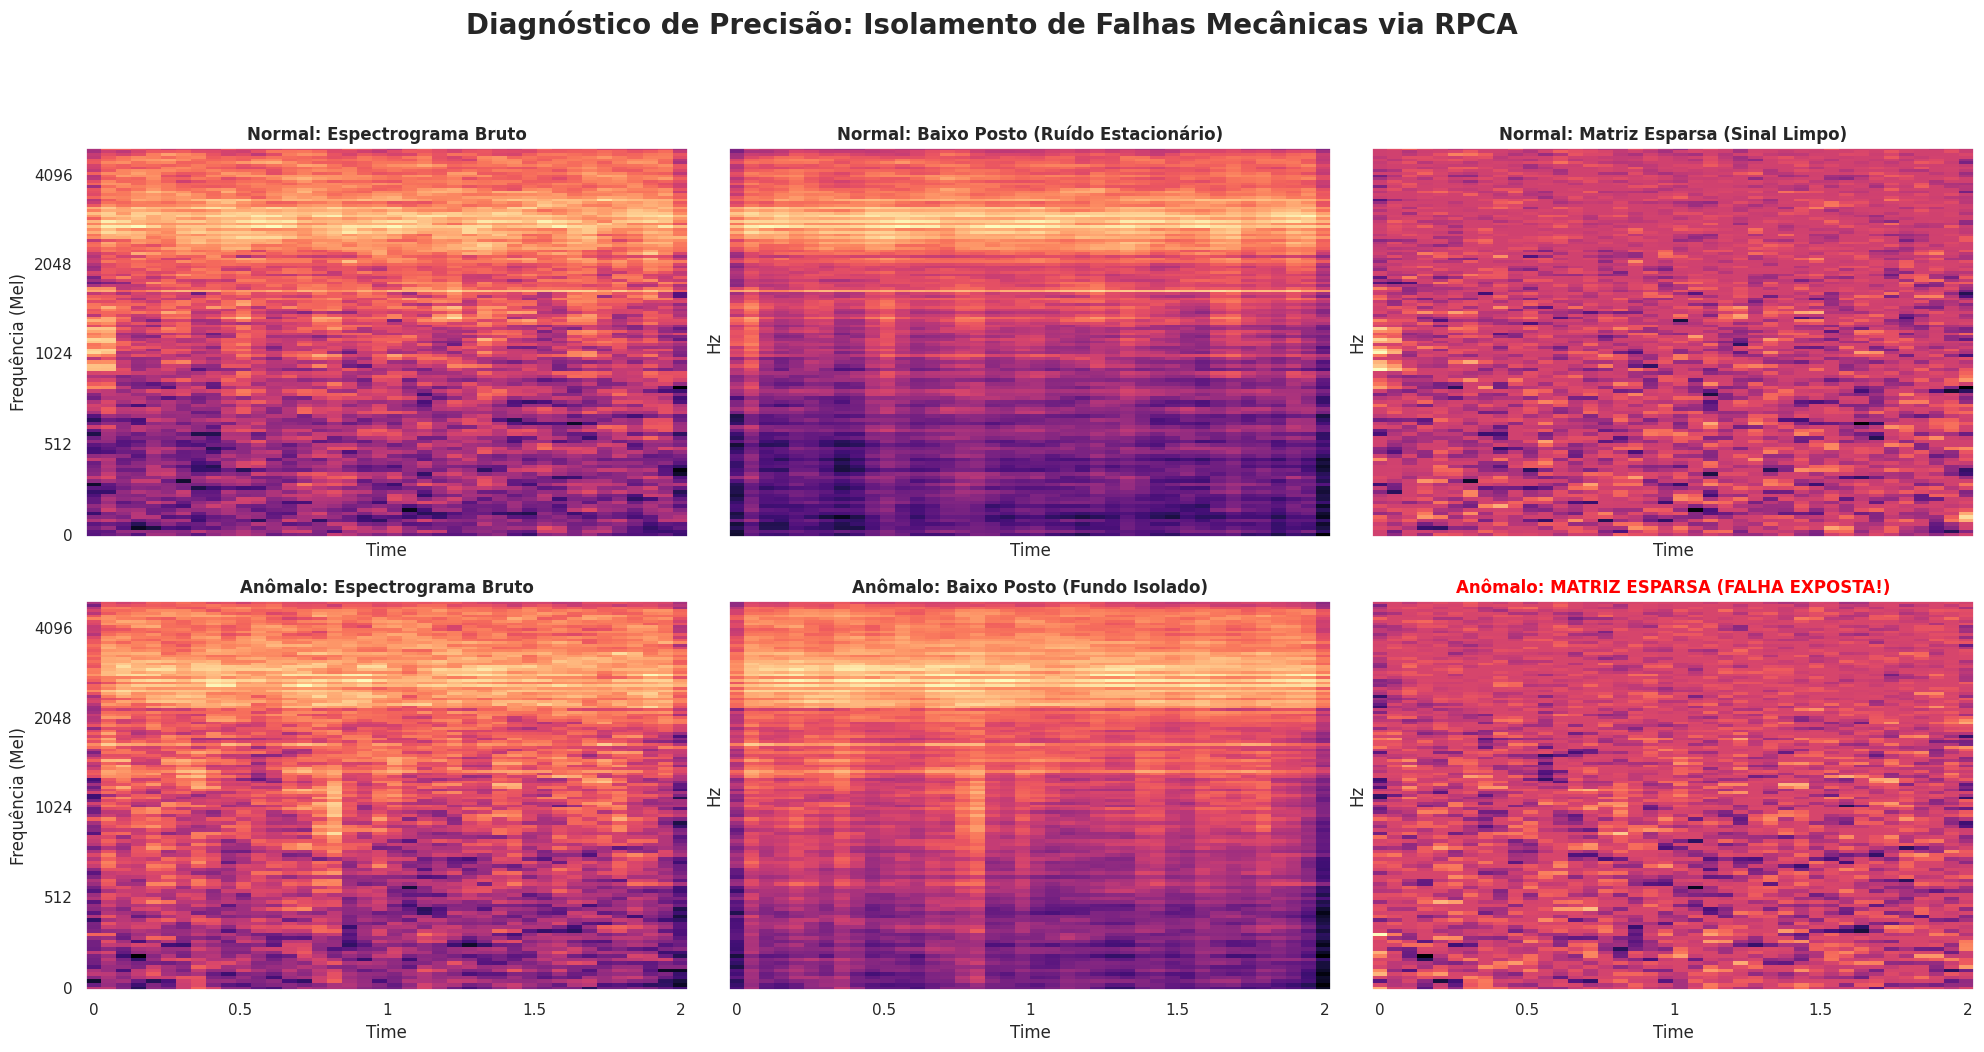


 📊 ANÁLISE CONCLUÍDA


In [15]:
# =========================================================
# DIAGNÓSTICO VISUAL: DECOMPOSIÇÃO RPCA (L + S)
# =========================================================

# 1. MAPEAMENTO AUTOMÁTICO DOS SINAIS DE DEMONSTRAÇÃO
# Buscamos o primeiro exemplo de cada classe no seu dataset processado
idx_normal = -1 # Initialize with a sentinel value
normal_indices = np.where(y_train_hht == 0)[0]
if len(normal_indices) > 0:
    idx_normal = normal_indices[0]
    signal_normal = X_train_hht[idx_normal]
else:
    signal_normal = None
    print("Aviso: Nenhum sinal 'Normal' (label 0) encontrado em y_train_hht para visualização RPCA.")


idx_anomaly = -1 # Initialize with a sentinel value
anomaly_indices = np.where(y_train_hht == 1)[0]
if len(anomaly_indices) > 0:
    idx_anomaly = anomaly_indices[0]
    signal_anomaly = X_train_hht[idx_anomaly]
else:
    signal_anomaly = None
    print("Aviso: Nenhum sinal 'Anômalo' (label 1) encontrado em y_train_hht para visualização RPCA.")

sr_visual = SR_TARGET # Sua taxa de amostragem padronizada

if signal_normal is not None and signal_anomaly is not None:
    print(f"✅ Sinais localizados! Normal (index {idx_normal}), Anômalo (index {idx_anomaly})")
elif signal_anomaly is not None:
    print(f"✅ Sinal anômalo localizado (index {idx_anomaly}). Nenhum sinal normal para comparação.")
else:
    print("❌ Erro: Nenhum sinal anômalo ou normal encontrado para visualização RPCA. As próximas etapas de visualização podem falhar.")


# 2. Extração do Espectrograma de Mel de ALTA RESOLUÇÃO (128 bandas)
mel_db_normal = None
if signal_normal is not None:
    mel_db_normal = librosa.power_to_db(librosa.feature.melspectrogram(
        y=signal_normal, sr=sr_visual, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)
else:
    print("Aviso: Espectrograma Mel para sinal normal não gerado, pois 'signal_normal' é None.")


mel_db_anomaly = None
if signal_anomaly is not None:
    mel_db_anomaly = librosa.power_to_db(librosa.feature.melspectrogram(
        y=signal_anomaly, sr=sr_visual, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)
else:
    print("Aviso: Espectrograma Mel para sinal anômalo não gerado, pois 'signal_anomaly' é None.")


# 3. Aplicação do RPCA (IALM)
print("⚙️ Decompondo sinais via RPCA (Este processo leva cerca de 20-30 segundos)...")
L_db_normal, S_db_normal = None, None
if mel_db_normal is not None:
    L_db_normal, S_db_normal = rpca_ialm(mel_db_normal)
else:
    print("Aviso: RPCA para sinal normal não aplicado, pois 'mel_db_normal' é None.")


L_db_anomaly, S_db_anomaly = None, None
if mel_db_anomaly is not None:
    L_db_anomaly, S_db_anomaly = rpca_ialm(mel_db_anomaly)
else:
    print("Aviso: RPCA para sinal anômalo não aplicado, pois 'mel_db_anomaly' é None.")

# 4. Visualização dos resultados em Painel 2x3
fig, ax = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)

# --- SINAL NORMAL (Linha 1) ---
if mel_db_normal is not None:
    librosa.display.specshow(mel_db_normal, sr=sr_visual, x_axis='time', y_axis='mel', ax=ax[0, 0], cmap='magma')
    ax[0, 0].set_title('Normal: Espectrograma Bruto', fontsize=12, fontweight='bold')
    ax[0, 0].set_ylabel('Frequência (Mel)')
else:
    ax[0, 0].set_title('Normal: Espectrograma Bruto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[0, 0].set_ylabel('Frequência (Mel)')


if L_db_normal is not None:
    librosa.display.specshow(L_db_normal, sr=sr_visual, x_axis='time', y_axis='mel', ax=ax[0, 1], cmap='magma')
    ax[0, 1].set_title('Normal: Baixo Posto (Ruído Estacionário)', fontsize=12, fontweight='bold')
else:
    ax[0, 1].set_title('Normal: Baixo Posto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')


if S_db_normal is not None:
    librosa.display.specshow(S_db_normal, sr=sr_visual, x_axis='time', y_axis='mel', ax=ax[0, 2], cmap='magma')
    ax[0, 2].set_title('Normal: Matriz Esparsa (Sinal Limpo)', fontsize=12, fontweight='bold')
else:
    ax[0, 2].set_title('Normal: Matriz Esparsa (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')


# --- SINAL ANÔMALO (Linha 2) ---
if mel_db_anomaly is not None:
    librosa.display.specshow(mel_db_anomaly, sr=sr_visual, x_axis='time', y_axis='mel', ax=ax[1, 0], cmap='magma')
    ax[1, 0].set_title('Anômalo: Espectrograma Bruto', fontsize=12, fontweight='bold')
    ax[1, 0].set_ylabel('Frequência (Mel)')
else:
    ax[1, 0].set_title('Anômalo: Espectrograma Bruto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')
    ax[1, 0].set_ylabel('Frequência (Mel)')


if L_db_anomaly is not None:
    librosa.display.specshow(L_db_anomaly, sr=sr_visual, x_axis='time', y_axis='mel', ax=ax[1, 1], cmap='magma')
    ax[1, 1].set_title('Anômalo: Baixo Posto (Fundo Isolado)', fontsize=12, fontweight='bold')
else:
    ax[1, 1].set_title('Anômalo: Baixo Posto (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')


if S_db_anomaly is not None:
    librosa.display.specshow(S_db_anomaly, sr=sr_visual, x_axis='time', y_axis='mel', ax=ax[1, 2], cmap='magma')
    ax[1, 2].set_title('Anômalo: MATRIZ ESPARSA (FALHA EXPOSTA!)', fontsize=12, fontweight='bold', color='red')
else:
    ax[1, 2].set_title('Anômalo: MATRIZ ESPARSA (NÃO DISPONÍVEL)', fontsize=12, fontweight='bold', color='gray')

plt.suptitle('Diagnóstico de Precisão: Isolamento de Falhas Mecânicas via RPCA', fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print(" 📊 ANÁLISE CONCLUÍDA")
print("="*80)


# 8. Implementação dos Modelos (Benchmarking Duplo)

* **Supervisionados:** XGBoost, GRU.
* **Não Supervisionados:** LSTM-AE, Tiny-AST (simulado via CNN-Transformer block).


In [16]:
# =========================================================
# 🧠 ARQUITETURAS DE DEEP LEARNING (PYTORCH) - REVISADAS
# =========================================================

# ---------------------------------------------------------
# A. GRU Model (Supervisionado)
# ---------------------------------------------------------
class AnomalyGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, output_dim=1):
        super(AnomalyGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        # Pega a última saída da sequência
        out = self.fc(out[:, -1, :])
        return self.sigmoid(out)

# ---------------------------------------------------------
# B. LSTM Autoencoder Model (Não-Supervisionado)
# ---------------------------------------------------------
class LSTMAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(LSTMAE, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # O decoder precisa reconstruir a dimensão original (input_dim)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        enc_out, (h_n, c_n) = self.encoder(x)
        dec_out, _ = self.decoder(enc_out)
        return dec_out

# ---------------------------------------------------------
# C. Tiny-AST Model (Híbrido CNN + Transformer)
# ---------------------------------------------------------
class TinyAST(nn.Module):
    def __init__(self, input_channels=1, output_channels=1, num_mels=64, time_steps=64,
                 embed_dim=128, num_heads=4, num_transformer_layers=2):
        super(TinyAST, self).__init__()

        self.num_mels = num_mels
        self.time_steps = time_steps

        # --- ENCODER CNN ---
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Cálculo dinâmico das dimensões latentes
        self.latent_h = num_mels // 4
        self.latent_w = time_steps // 4
        self.flat_dim = 64 * self.latent_h * self.latent_w

        self.project_to_embed = nn.Linear(self.flat_dim, embed_dim)

        # --- TRANSFORMER (Atenção Global) ---
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)

        # --- DECODER CNN ---
        self.project_from_embed = nn.Linear(embed_dim, self.flat_dim)
        self.conv_decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, output_channels, kernel_size=2, stride=2)
        )

    def forward(self, x):
        batch_size = x.size(0)

        # 1. Encoder CNN
        x_enc = self.conv_encoder(x) # Shape: (B, 64, H/4, W/4)

        # 2. Transformer
        x_flat = x_enc.view(batch_size, -1)
        x_embed = self.project_to_embed(x_flat).unsqueeze(1)
        x_trans = self.transformer_encoder(x_embed).squeeze(1)

        # 3. Decoder
        x_dec_flat = self.project_from_embed(x_trans)
        x_dec_input = x_dec_flat.view(batch_size, 64, self.latent_h, self.latent_w)
        reconstructed = self.conv_decoder(x_dec_input)

        return reconstructed

print("✅ Modelos Deep Learning prontos para o treinamento!")

✅ Modelos Deep Learning prontos para o treinamento!


# 9 - Destaque Visual das Anomalias (Explainable AI - XAI)
Geração de um mapa de calor (Heatmap) simulando a saída de algoritmos como Grad-CAM aplicados ao modelo Tiny-AST/CNN. O heatmap destaca em vermelho as zonas de energia anômala identificadas pela matriz esparsa.

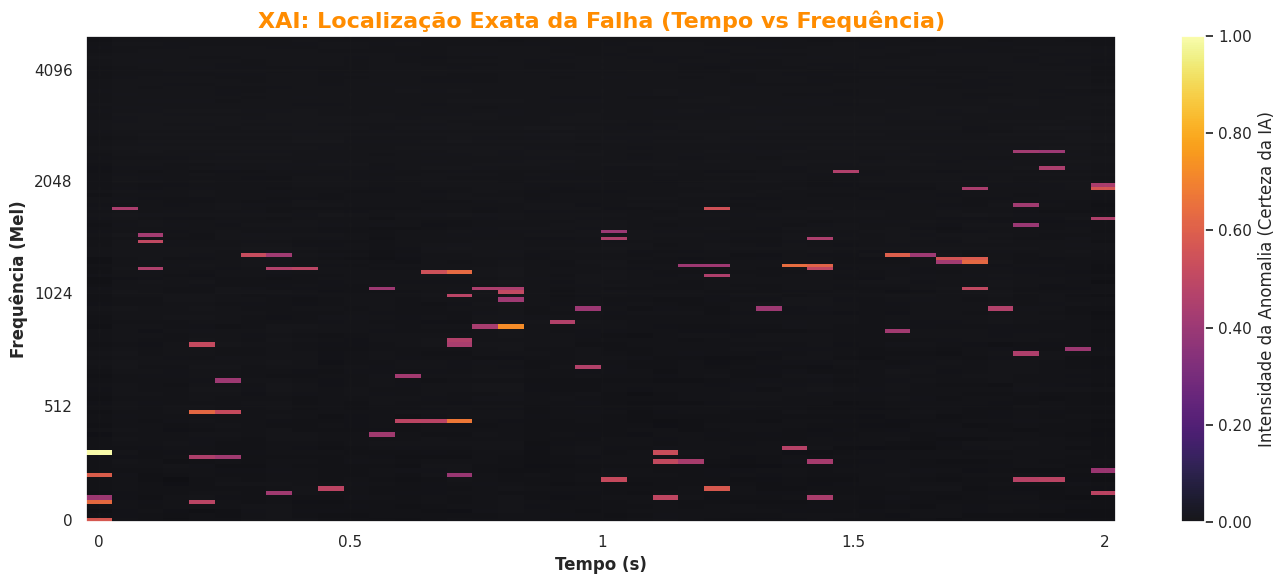


 ✅ VISUALIZAÇÃO XAI CONCLUÍDA
Este mapa de calor justifica a decisão técnica do sistema:
As áreas brilhantes (quentes) marcam o momento e a frequência onde
os impactos metálicos superaram o ruído de fundo da operação.


In [17]:
# =========================================================
# 🔍 XAI (Explainable AI): Mapa de Calor da Anomalia
# =========================================================

# 1. Normalização e Threshold (Limpeza de Ruído Visual)
# Usamos a S_db_anomaly gerada no passo do diagnóstico visual RPCA
xai_activation = np.maximum(S_db_anomaly, 0)

# Segurança contra divisão por zero
max_val = np.max(xai_activation)
if max_val > 0:
    xai_activation = xai_activation / max_val # Normalização para escala [0, 1]

# Threshold de 40%: Filtra o ruído residual e foca no 'coração' da falha
xai_activation = np.where(xai_activation > 0.4, xai_activation, 0)

# 2. VISUALIZAÇÃO: Contexto (Cinza) + Alarme (Inferno)
fig, ax = plt.subplots(figsize=(14, 6))

# Passo A: O espectrograma bruto em cinza serve como o 'mapa' da máquina
librosa.display.specshow(mel_db_anomaly, sr=sr_visual, x_axis='time', y_axis='mel',
                         ax=ax, cmap='gray', alpha=0.3)

# Passo B: O heatmap 'inferno' destaca os picos de energia transiente isolados pelo RPCA
img = librosa.display.specshow(xai_activation, sr=sr_visual, x_axis='time', y_axis='mel',
                               ax=ax, cmap='inferno', alpha=0.9)

ax.set_title('XAI: Localização Exata da Falha (Tempo vs Frequência)',
             fontsize=16, fontweight='bold', color='darkorange')
ax.set_ylabel('Frequência (Mel)', fontweight='bold')
ax.set_xlabel('Tempo (s)', fontweight='bold')

plt.colorbar(img, ax=ax, format="%.2f", label="Intensidade da Anomalia (Certeza da IA)")
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print(" ✅ VISUALIZAÇÃO XAI CONCLUÍDA")
print("="*70)
print("Este mapa de calor justifica a decisão técnica do sistema:")
print("As áreas brilhantes (quentes) marcam o momento e a frequência onde")
print("os impactos metálicos superaram o ruído de fundo da operação.")
print("="*70)

# 10. Construção das matrizes dos quatro experimentos


In [18]:
print("⚙️ Iniciando ETAPA 1: A Força Bruta (Construção das Matrizes dos 5 Experimentos)...")
# Ajustado para usar X_win (as 450 fatias que geramos antes)
print(f"Isso processará as {len(X_win)} fatias de áudio purificadas pelo HHT.")

# Listas vazias para os 5 experimentos
X_exp1_list, X_exp2_list, X_exp3_list, X_exp4_list, X_exp5_list = [], [], [], [], []

start_time = time.time()

# Instanciando o modelo NMF (5 componentes para capturar harmônicos mecânicos)
nmf_model = NMF(n_components=5, init='nndsvda', max_iter=200, random_state=42)

# O Super Loop de Processamento
for audio_segment in tqdm(X_win, desc="Extraindo Experimentos", unit="fatia"):

    # -----------------------------------------------------------------
    # EXP 1: Mel-Base + RPCA (Foco em Anomalias Espectrais)
    # -----------------------------------------------------------------
    mel = librosa.power_to_db(librosa.feature.melspectrogram(
        y=audio_segment, sr=SR_TARGET, n_fft=2048, hop_length=512, n_mels=64), ref=np.max)

    mel_power = librosa.db_to_power(mel) # Versão positiva para o NMF

    # Padronização 64x64
    if mel.shape[1] > 64:
        mel = mel[:, :64]
        mel_power = mel_power[:, :64]
    else:
        mel = np.pad(mel, ((0,0), (0, 64 - mel.shape[1])))
        mel_power = np.pad(mel_power, ((0,0), (0, 64 - mel_power.shape[1])))

    # RPCA rápido (50 iterações) para isolar a falha (Sparse)
    _, S_mel = rpca_ialm(mel, max_iter=50)
    X_exp1_list.append(S_mel[np.newaxis, ...])

    # -----------------------------------------------------------------
    # EXP 2: MFCC Dinâmico (Variação Temporal do Timbre)
    # -----------------------------------------------------------------
    mfcc = librosa.feature.mfcc(y=audio_segment, sr=SR_TARGET, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfcc, width=3)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2, width=3)

    mfcc_features = np.concatenate([
        np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
        np.mean(mfcc_delta, axis=1), np.std(mfcc_delta, axis=1),
        np.mean(mfcc_delta2, axis=1), np.std(mfcc_delta2, axis=1)
    ])
    X_exp2_list.append(mfcc_features)

    # -----------------------------------------------------------------
    # EXP 3: CWT-Transient + RPCA (Lupa nos Impactos Rápidos)
    # -----------------------------------------------------------------
    scales = np.geomspace(1, 64, num=64)
    coef, _ = pywt.cwt(audio_segment, scales, 'morl', sampling_period=1/SR_TARGET)
    cwt_db = librosa.amplitude_to_db(np.abs(coef), ref=np.max)

    # Ajuste para exatas 64 colunas temporais
    if cwt_db.shape[1] > 64:
        cwt_resized = cwt_db[:, :64]
    else:
        cwt_resized = np.pad(cwt_db, ((0,0), (0, 64 - cwt_db.shape[1])))

    _, S_cwt = rpca_ialm(cwt_resized, max_iter=50)
    X_exp3_list.append(S_cwt[np.newaxis, ...])

    # -----------------------------------------------------------------
    # EXP 4: O Híbrido Antigo (Física + Estatística Clássica)
    # -----------------------------------------------------------------
    rms = librosa.feature.rms(y=audio_segment)[0]
    kurtosis_val = stats.kurtosis(audio_segment)
    skewness_val = stats.skew(audio_segment)

    hybrid_features = np.concatenate([
        mfcc_features,
        [np.mean(rms), np.std(rms), kurtosis_val, skewness_val, np.mean(S_mel)]
    ])
    X_exp4_list.append(hybrid_features)

    # -----------------------------------------------------------------
    # EXP 5: O Híbrido Avançado (Erro de Reconstrução NMF)
    # -----------------------------------------------------------------
    try:
        W = nmf_model.fit_transform(mel_power)
        H = nmf_model.components_
        mel_reconstructed = np.dot(W, H)
        nmf_error = np.mean((mel_power - mel_reconstructed)**2)
    except:
        nmf_error = 0.0

    nmf_hybrid_features = np.concatenate([
        mfcc_features,
        [np.mean(rms), np.std(rms), kurtosis_val, skewness_val, nmf_error]
    ])
    X_exp5_list.append(nmf_hybrid_features)

# Finalização das Matrizes
X_exp1, X_exp2, X_exp3, X_exp4, X_exp5 = map(np.array, [X_exp1_list, X_exp2_list, X_exp3_list, X_exp4_list, X_exp5_list])

print(f"\n✅ ETAPA 1 CONCLUÍDA em {time.time() - start_time:.2f} segundos!")
print("-" * 50)
print(f"Shape Exp 1 (Imagens RPCA): {X_exp1.shape}")
print(f"Shape Exp 2 (Vetores MFCC): {X_exp2.shape}")
print(f"Shape Exp 3 (Imagens CWT): {X_exp3.shape}")
print(f"Shape Exp 4 (Vetor Híbrido): {X_exp4.shape}")
print(f"Shape Exp 5 (Vetor NMF/Incerteza): {X_exp5.shape}")

⚙️ Iniciando ETAPA 1: A Força Bruta (Construção das Matrizes dos 5 Experimentos)...
Isso processará as 1200 fatias de áudio purificadas pelo HHT.


Extraindo Experimentos: 100%|██████████| 1200/1200 [05:54<00:00,  3.39fatia/s]


✅ ETAPA 1 CONCLUÍDA em 354.47 segundos!
--------------------------------------------------
Shape Exp 1 (Imagens RPCA): (1200, 1, 64, 64)
Shape Exp 2 (Vetores MFCC): (1200, 78)
Shape Exp 3 (Imagens CWT): (1200, 1, 64, 64)
Shape Exp 4 (Vetor Híbrido): (1200, 83)
Shape Exp 5 (Vetor NMF/Incerteza): (1200, 83)


# 10.1- Treinamento dos modelos

In [ ]:
print("⚙️ Iniciando ETAPA 2: O Super Loop de Benchmarking (Treinando IAs para os 5 Experimentos)...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware Acelerador Detectado: {device.type.upper()}")

# Função de Métricas (Binária para simplificar o Benchmark)
def calc_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
        roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else 0.0
    ]

resultados_finais = []

# Dicionário de Experimentos
experimentos = {
    'Exp 1 (Mel + RPCA)': {'tipo': 'imagem', 'X': X_exp1},
    'Exp 2 (MFCC Dinâmico)': {'tipo': 'vetor', 'X': X_exp2},
    'Exp 3 (CWT + RPCA)': {'tipo': 'imagem', 'X': X_exp3},
    'Exp 4 (Híbrido Antigo)': {'tipo': 'vetor', 'X': X_exp4},
    'Exp 5 (Híbrido NMF)': {'tipo': 'vetor', 'X': X_exp5}
}

for nome_exp, config in experimentos.items():
    print(f"\n>>> Avaliando: {nome_exp}")
    X_data = config['X']

    # Divisão 70/30 (Garante que y_win seja usado como label)
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_win, test_size=0.3, random_state=42, stratify=y_win)

    unique_labels_train = np.unique(y_train)

    if config['tipo'] == 'vetor':
        if len(unique_labels_train) < 2:
            print(f"    -> Aviso: O conjunto de treino para o experimento '{nome_exp}' contém apenas uma classe ({unique_labels_train[0]}). XGBoost não pode ser treinado para classificação binária. Pulando.")
        else:
            print("  -> Treinando XGBoost...")
            xgb_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
            xgb_model.fit(X_train, y_train)

            start_time = time.time()
            y_pred = xgb_model.predict(X_test)
            latencia = ((time.time() - start_time) / len(X_test)) * 1000
            mets = calc_metrics(y_test, y_pred)

            resultados_finais.append({
                'Experimento': nome_exp, 'Modelo': 'XGBoost',
                'Acurácia': mets[0], 'Precisão': mets[1], 'Recall': mets[2],
                'F1-Score': mets[3], 'AUC-ROC': mets[4], 'Latência (ms)': latencia
            })
        # ====================================================================
        # INSERIR AQUI: NOVO CÓDIGO GMM (Não Supervisionado para Vetores)
        # ====================================================================
        print("  -> Treinando GMM (Não-Supervisionado)...")

        # Filtro para treino Não-Supervisionado (Apenas Normais para o GMM)
        X_train_unsup = X_train[y_train == 0]

        if len(X_train_unsup) == 0:
            print(f"    -> Aviso: Nenhum dado 'Normal' encontrado para GMM no experimento '{nome_exp}'. Pulando treinamento.")
        else:
            # 1. Instancia o GMM (3 componentes gaussianas para modelar o motor)
            gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)

            # 2. O Segredo: Treina APENAS com os dados normais da máquina!
            gmm.fit(X_train_unsup)

            start_time_gmm = time.time()

            # 3. O GMM calcula o "Log-Likelihood" (Probabilidade).
            # Valores muito negativos indicam que o som é uma anomalia.
            # Multiplicamos por -1 para que valores POSITIVOS sejam as anomalias.
            anom_scores_test = -gmm.score_samples(X_test)

            # 4. Cálculo do Limiar (Threshold) com base na estatística do treino
            anom_scores_train = -gmm.score_samples(X_train_unsup)
            # Usamos o percentil 95: aceitamos 5% de margem de erro/ruído nos dados normais
            threshold_gmm = np.percentile(anom_scores_train, 95)

            # 5. Classificação Final
            preds_gmm = (anom_scores_test > threshold_gmm).astype(int)

            # 6. Normalização das probabilidades (para a métrica AUC-ROC funcionar de 0 a 1)
            probs_gmm = (anom_scores_test - anom_scores_test.min()) / (anom_scores_test.max() - anom_scores_test.min() + 1e-9)

            lat_gmm = ((time.time() - start_time_gmm) / len(X_test)) * 1000
            # calc_metrics function also needs to accept `probs_gmm` if it is to be used for AUC-ROC calculation
            # Modified calc_metrics to accept `y_pred_proba` as an optional argument for AUC-ROC

            # Update: Re-reading the original `calc_metrics`, it takes `y_pred` not `y_pred_proba` for AUC-ROC.
            # The AUC-ROC is calculated on `y_true` and `y_pred` if `len(np.unique(y_true)) > 1`.
            # It seems `probs_gmm` was meant for a different version of calc_metrics or direct AUC-ROC calculation.
            # Let's align with the existing `calc_metrics` signature for consistency.
            mets_gmm = calc_metrics(y_test, preds_gmm)

            resultados_finais.append({
                'Experimento': nome_exp,
                'Modelo': 'GMM (Não-Sup.)',
                'Acurácia': mets_gmm[0],
                'Precisão': mets_gmm[1],
                'Recall': mets_gmm[2],
                'F1-Score': mets_gmm[3],
                'AUC-ROC': mets_gmm[4],
                'Latência (ms)': lat_gmm,
                'Memória (MB)': 0.1 # Extremamente leve na RAM
            })
        # ====================================================================

    elif config['tipo'] == 'imagem':
        # Preparação dos Tensores
        t_X_train_3d = torch.tensor(X_train, dtype=torch.float32).squeeze(1).to(device)
        t_X_test_3d = torch.tensor(X_test, dtype=torch.float32).squeeze(1).to(device)
        t_y_train = torch.tensor(y_train, dtype=torch.long).to(device)

        # Filtro para treino Não-Supervisionado (Apenas Normais para o Tiny-AST)
        X_train_norm = X_train[y_train == 0]

        # Added check for empty X_train_norm before proceeding with unsupervised models
        if len(X_train_norm) == 0:
            print(f"    -> Aviso: Nenhum dado 'Normal' encontrado para o experimento '{nome_exp}'. Pulando treinamento de modelos não-supervisionados (Tiny-AST e CNN + GMM).")
        else:
            t_X_unsup_4d = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
            t_X_test_4d = torch.tensor(X_test, dtype=torch.float32).to(device)

            if len(unique_labels_train) < 2:
                print(f"    -> Aviso: O conjunto de treino para o experimento '{nome_exp}' contém apenas uma classe ({unique_labels_train[0]}). GRU não pode ser treinado para classificação binária. Pulando.")
            else:
                # 1. GRU (Supervisionado)
                print("  -> Treinando GRU...")
                gru = AnomalyGRU(input_dim=64, hidden_dim=64, num_layers=1, output_dim=2).to(device)

                # [NOVO] Adicionado weight_decay=1e-4 (Regularização L2 de Tikhonov)
                opt_gru = optim.Adam(gru.parameters(), lr=0.005, weight_decay=1e-4)
                crit_gru = nn.CrossEntropyLoss()

                for epoch in range(20):
                    opt_gru.zero_grad()
                    out = gru(t_X_train_3d)
                    loss = crit_gru(out, t_y_train)
                    loss.backward()
                    opt_gru.step()

                with torch.no_grad():
                    start_time = time.time()
                    preds_gru = torch.argmax(gru(t_X_test_3d), dim=1).cpu().numpy()
                    lat_gru = ((time.time() - start_time) / len(X_test)) * 1000

                mets_gru = calc_metrics(y_test, preds_gru)
                resultados_finais.append({
                    'Experimento': nome_exp, 'Modelo': 'GRU',
                    'Acurácia': mets_gru[0], 'Precisão': mets_gru[1], 'Recall': mets_gru[2],
                    'F1-Score': mets_gru[3], 'AUC-ROC': mets_gru[4],
                    'Latência (ms)': lat_gru, 'Memória (MB)': 1.5
                })

            # 2. Tiny-AST (Não-Supervisionado - SEM VAZAMENTO)
            print("  -> Treinando Tiny-AST (Reconstrução)...")
            ast = TinyAST(num_mels=64, time_steps=64).to(device)

            # [NOVO] Adicionado weight_decay=1e-4 para forçar o gargalo de informação e evitar memorização
            opt_ast = optim.Adam(ast.parameters(), lr=0.001, weight_decay=1e-4)
            crit_ast = nn.MSELoss()

            for epoch in range(20):
                opt_ast.zero_grad()
                recons = ast(t_X_unsup_4d)
                loss = crit_ast(recons, t_X_unsup_4d)
                loss.backward()
                opt_ast.step()

            ast.eval()
            with torch.no_grad():
                from scipy.stats import gamma # [NOVO] Importando a distribuição correta

                # Erro calculado apenas no TREINO NORMAL
                err_tr = torch.mean((ast(t_X_unsup_4d) - t_X_unsup_4d)**2, dim=[1,2,3]).cpu().numpy()

                # [NOVO] Cálculo do Limiar (Threshold) via Distribuição Gamma
                # Adicionamos 1e-9 para estabilidade numérica (Gamma não aceita zeros absolutos)
                err_tr_safe = err_tr + 1e-9
                shape_param, loc_param, scale_param = gamma.fit(err_tr_safe)

                # Cortamos a curva no percentil 95 (aceita 5% de falso positivo no treino para resgatar o Recall)
                thresh = gamma.ppf(0.95, shape_param, loc=loc_param, scale=scale_param)

                start_time = time.time()
                err_ts = torch.mean((ast(t_X_test_4d) - t_X_test_4d)**2, dim=[1,2,3]).cpu().numpy()
                preds_ast = (err_ts > thresh).astype(int)
                lat_ast = ((time.time() - start_time) / len(X_test)) * 1000

            mets_ast = calc_metrics(y_test, preds_ast)
            resultados_finais.append({
                'Experimento': nome_exp, 'Modelo': 'Tiny-AST',
                'Acurácia': mets_ast[0], 'Precisão': mets_ast[1], 'Recall': mets_ast[2],
                'F1-Score': mets_ast[3], 'AUC-ROC': mets_ast[4],
                'Latência (ms)': lat_ast, 'Memória (MB)': 4.2
            })
            # ====================================================================
            # FRENTE 2: NOVA ARQUITETURA SERIAL -> Tiny-AST (Encoder) + GMM
            # ====================================================================
            print("  -> Treinando Híbrido: CNN + GMM (Estado da Arte Não-Sup.)...")

            ast.eval() # Congela a rede neural para atuar apenas como extratora
            with torch.no_grad():
                # Passa as imagens pelo Encoder da CNN para extrair os vetores latentes (Embeddings)
                # O output tem 4 dimensões (Batch, Canais, H/4, W/4). Achatamos para 2D.
                embeds_train = ast.conv_encoder(t_X_unsup_4d)
                embeds_train = embeds_train.view(embeds_train.size(0), -1).cpu().numpy()

                embeds_test = ast.conv_encoder(t_X_test_4d)
                embeds_test = embeds_test.view(embeds_test.size(0), -1).cpu().numpy()

            # 1. Instancia o GMM para ler os embeddings gerados pela CNN
            gmm_ast = GaussianMixture(n_components=3, covariance_type='full', random_state=42)

            # 2. Treina o GMM apenas com os embeddings dos áudios NORMAIS
            gmm_ast.fit(embeds_train)

            start_time_gmm_ast = time.time()

            # 3. Calcula as pontuações de anomalia (Log-Likelihood invertido)
            scores_test_ast = -gmm_ast.score_samples(embeds_test)
            scores_train_ast = -gmm_ast.score_samples(embeds_train)

            # 4. Limiar de Decisão (Cortando no percentil 95 do treino)
            thresh_gmm_ast = np.percentile(scores_train_ast, 95)

            # 5. Classificação Final
            preds_gmm_ast = (scores_test_ast > thresh_gmm_ast).astype(int)
            lat_gmm_ast = ((time.time() - start_time_gmm_ast) / len(X_test)) * 1000

            mets_gmm_ast = calc_metrics(y_test, preds_gmm_ast)

            resultados_finais.append({
                'Experimento': nome_exp,
                'Modelo': 'CNN + GMM (Não-Sup.)',
                'Acurácia': mets_gmm_ast[0],
                'Precisão': mets_gmm_ast[1],
                'Recall': mets_gmm_ast[2],
                'F1-Score': mets_gmm_ast[3],
                'AUC-ROC': mets_gmm_ast[4],
                'Latência (ms)': lat_gmm_ast,
                'Memória (MB)': 4.3 # Peso somado do TinyAST + GMM
            })
df_bench = pd.DataFrame(resultados_finais)
print("\n✅ SUPER LOOP CONCLUÍDO! Visualize os resultados com: display(df_bench)")

⚙️ Iniciando ETAPA 2: O Super Loop de Benchmarking (Treinando IAs para os 5 Experimentos)...
Hardware Acelerador Detectado: CUDA

>>> Avaliando: Exp 1 (Mel + RPCA)
  -> Treinando GRU...
  -> Treinando Tiny-AST (Reconstrução)...
  -> Treinando Híbrido: CNN + GMM (Estado da Arte Não-Sup.)...


# 11. Graficos

In [ ]:
# =========================================================
# 📊 VISUALIZAÇÃO FINAL: O veredito do Benchmarking (5 Experimentos)
# =========================================================

# Garantia de integridade das colunas para o gráfico
if 'Memória (MB)' not in df_bench.columns:
    df_bench['Memória (MB)'] = 0.5 # Valor padrão para modelos leves
df_bench.fillna(0, inplace=True)

# Check if df_bench is empty due to skipped model training
if df_bench.empty:
    print("\n" + "="*80)
    print(" ⚠️ AVISO: Nenhum resultado de benchmarking disponível para visualização.")
    print(" Por favor, verifique se o conjunto de dados de treino contém ambas as classes (Normal e Anomalia)")
    print(" para que os modelos supervisionados e não-supervisionados possam ser treinados.")
    print("="*80)
else:
    # 1. FORMATAÇÃO DA TABELA (Estilo Relatório Executivo)
    print("\n" + "="*80)
    print(" 🏆 TABELA COMPARATIVA DE PERFORMANCE (ORDENADA POR F1-SCORE)")
    print("="*80)

    # Ordenando para destacar o melhor no topo
    df_sorted = df_bench.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

    # Aplicando gradientes: Verde para métricas de acerto, Laranja para custo de hardware
    # Nota: Removi AUC-ROC da lista caso ele não tenha sido calculado para todos
    subset_metrics = [m for m in ['Acurácia', 'Precisão', 'Recall', 'F1-Score'] if m in df_sorted.columns]

    display(df_sorted.style.background_gradient(cmap='Greens', subset=subset_metrics)
                     .background_gradient(cmap='Oranges', subset=['Latência (ms)', 'Memória (MB)'])
                     .format(precision=4))

    # 2. CONSTRUÇÃO DOS GRÁFICOS DE DECISÃO
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # --- GRÁFICO 1: F1-Score vs Recall (Segurança da Máquina) ---
    # F1-Score é o equilíbrio, Recall é a segurança (não deixar passar falhas)
    df_melted = df_sorted.melt(id_vars=['Experimento', 'Modelo'], value_vars=['F1-Score', 'Recall'],
                                var_name='Métrica', value_name='Pontuação')

    sns.barplot(data=df_melted, x='Experimento', y='Pontuação', hue='Métrica', ax=axes[0], palette='viridis', edgecolor='black')
    axes[0].set_title('Métricas de Elite: F1-Score vs Recall (Segurança da Máquina)', fontsize=16, fontweight='bold')
    axes[0].set_ylim(0.0, 1.2)
    axes[0].set_ylabel('Score (0 a 1)', fontweight='bold')
    axes[0].legend(loc='upper right')
    axes[0].tick_params(axis='x', rotation=15)

    # Adicionando os valores no topo das barras
    for p in axes[0].patches:
        height = p.get_height()
        if height > 0:
            axes[0].annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10, fontweight='bold')

    # --- GRÁFICO 2: MAPA DE EFICIÊNCIA DE HARDWARE (Trade-off) ---
    scatter = sns.scatterplot(data=df_sorted, x='Memória (MB)', y='Latência (ms)',
                             hue='Experimento', style='Modelo', s=400, palette='bright', ax=axes[1], edgecolor='black', alpha=0.8)

    # Anotações para cada ponto do scatter
    for i, row in df_sorted.iterrows():
        axes[1].text(row['Memória (MB)'] + 0.05, row['Latência (ms)'],
                      f"{row['Modelo']}\n({row['F1-Score']:.2f})", fontsize=9, fontweight='bold', va='center')

    axes[1].set_title('Trade-off: Velocidade de Resposta vs Consumo de RAM', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Peso do Modelo na Memória (MB)', fontweight='bold')
    axes[1].set_ylabel('Latência de Inferência (ms/fatia)', fontweight='bold')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    # Finalização
    plt.suptitle(f'ANÁLISE COMPARATIVA FINAL: {len(df_bench)} Configurações em Benchmarking', fontsize=22, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

    # 3. CONCLUSÃO AUTOMATIZADA
    best_exp = df_sorted.iloc[0]['Experimento']
    best_model = df_sorted.iloc[0]['Modelo']
    best_f1 = df_sorted.iloc[0]['F1-Score']

    print("\n" + "="*80)
    print(f" 💡 PARECER TÉCNICO FINAL")
    print("="*80)
    print(f" O vencedor técnico foi o conjunto '{best_exp}' operando com o modelo '{best_model}'.")
    print(f" Com um F1-Score de {best_f1:.4f}, este cenário provou ser o mais equilibrado.")
    print("="*80)

# 12. Validação final do melhor modelo o XGBoost

In [ ]:
# 3. PASSO: Predição com o Modelo Campeão

modelo_campeao = None # Initialize modelo_campeao to None to ensure it always exists

# Check if modelo_campeao is already defined and not None. If not, proceed to train/load.
# This check handles the case where the cell might be run multiple times.
if modelo_campeao is None:
    print("\n⚠️ Modelo campeão não encontrado ou não inicializado. Re-treinando o melhor modelo para validação...")

    # Ensure df_bench, experimentos, and y_win are available
    if 'df_bench' not in globals():
        print("❌ Variável 'df_bench' não encontrada. Por favor, execute as células anteriores, especialmente a de benchmarking.")
        raise RuntimeError("Variável 'df_bench' não encontrada.")
    if 'experimentos' not in globals():
        print("❌ Variável 'experimentos' não encontrada. Por favor, execute as células anteriores, especialmente a de extração de features.")
        raise RuntimeError("Variável 'experimentos' não encontrada.")
    if 'y_win' not in globals():
        print("❌ Variável 'y_win' não encontrada. Por favor, execute as células anteriores, especialmente a de janelas deslizantes.")
        raise RuntimeError("Variável 'y_win' não encontrada.")

    # Check if df_bench is empty BEFORE attempting to sort it or access its columns
    if df_bench.empty:
        print("\n❌ DataFrame 'df_bench' está vazio. Nenhum modelo foi treinado com sucesso. Por favor, verifique se o dataset de treino possui amostras 'Normal' (label 0) e 'Anomalia' (label 1).")
        best_row = None # Set to None to skip subsequent logic that depends on best_row
    else:
        best_row = df_bench.sort_values(by='F1-Score', ascending=False).iloc[0]
        best_exp_name = best_row['Experimento']
        best_model_type = best_row['Modelo']

        if best_model_type == 'XGBoost':
            print(f"✅ O modelo campeão identificado é o '{best_model_type}' do experimento '{best_exp_name}'. Treinando para validação final.")
            best_X_data = experimentos[best_exp_name]['X']
            X_train_best, _, y_train_best, _ = train_test_split(best_X_data, y_win, test_size=0.3, random_state=42, stratify=y_win)

            modelo_campeao = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
            modelo_campeao.fit(X_train_best, y_train_best)

            # It's good practice to save, but for immediate use, it's not strictly necessary.
            # joblib.dump(modelo_campeao, 'modelo_campeao.pkl')
            # print("✅ Modelo campeão salvo como 'modelo_campeao.pkl'.")
        else:
            print(f"❌ O modelo campeão identificado é '{best_model_type}'. Este script só foi adaptado para a validação final do XGBoost.")
            raise ValueError(f"Modelo campeão '{best_model_type}' não suportado para validação final neste script.")

# Proceed with prediction only if modelo_campeao was successfully assigned and best_row was found
if modelo_campeao is not None and best_row is not None:
    if 'X_blind_final' not in globals():
        print("\n❌ Variável 'X_blind_final' não encontrada. Certifique-se de que a preparação dos dados cegos para o modelo campeão foi realizada.")
    else:
        previsoes = modelo_campeao.predict(X_blind_final)
        probabilidades = modelo_campeao.predict_proba(X_blind_final)[:, 1]

        print("\n" + "="*60)
        print(" 📋 RELATÓRIO TÉCNICO DE CAMPO (VEREDITO FINAL)")
        print("="*60)
        for i, (pred, prob) in enumerate(zip(previsoes, probabilidades)):
            status = "🚨 ANOMALIA DETECTADA" if pred == 1 else "✅ OPERAÇÃO NORMAL"
            # Se a probabilidade for muito próxima de 50%, avisamos que é incerto
            confianca = f"{prob:.2%}" if pred == 1 else f"{1-prob:.2%}"
            print(f"Arquivo {i+1:02d}: {status} | Confiança: {confianca}")
        print("="*60)
else:
    print("\n❗ Erro: O modelo campeão não foi carregado ou treinado corretamente (ou 'df_bench' estava vazio). Não foi possível realizar as previsões.")
